In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("shantanugarg274/heart-prediction-dataset-quantum")

print("Path to dataset files:", path)

100%|██████████| 6.83k/6.83k [00:00<00:00, 1.08MB/s]

Extracting files...
Path to dataset files: /root/.cache/kagglehub/datasets/shantanugarg274/heart-prediction-dataset-quantum/versions/1


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix


df = pd.read_csv("/root/.cache/kagglehub/datasets/shantanugarg274/heart-prediction-dataset-quantum/versions/1/Heart Prediction Quantum Dataset.csv")
df.head()

,Age,Gender,BloodPressure,Cholesterol,HeartRate,QuantumPatternFeature,HeartDisease
0,68,1,105,191,107,8.362241,1
1,58,0,97,249,89,9.249002,0
2,44,0,93,190,82,7.942542,1
3,72,1,93,183,101,6.495155,1
4,37,0,145,166,103,7.653900,1


# EDA


In [3]:
df.describe()

,Age,Gender,BloodPressure,Cholesterol,HeartRate,QuantumPatternFeature,HeartDisease
count,500.000000,500.000000,500.000000,500.00000,500.000000,500.000000,500.000000
mean,54.864000,0.468000,132.874000,221.50000,88.766000,8.317407,0.600000
std,14.315004,0.499475,26.418516,43.86363,17.417289,0.919629,0.490389
min,30.000000,0.000000,90.000000,150.00000,60.000000,6.164692,0.000000
25%,43.000000,0.000000,111.000000,183.75000,73.000000,7.675779,0.000000
50%,55.000000,0.000000,132.000000,221.00000,89.000000,8.323064,1.000000
75%,66.250000,1.000000,155.000000,258.00000,104.000000,8.935999,1.000000
max,79.000000,1.000000,179.000000,299.00000,119.000000,10.784886,1.000000


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 7 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Age                    500 non-null    int64  
 1   Gender                 500 non-null    int64  
 2   BloodPressure          500 non-null    int64  
 3   Cholesterol            500 non-null    int64  
 4   HeartRate              500 non-null    int64  
 5   QuantumPatternFeature  500 non-null    float64
 6   HeartDisease           500 non-null    int64  
dtypes: float64(1), int64(6)
memory usage: 27.5 KB


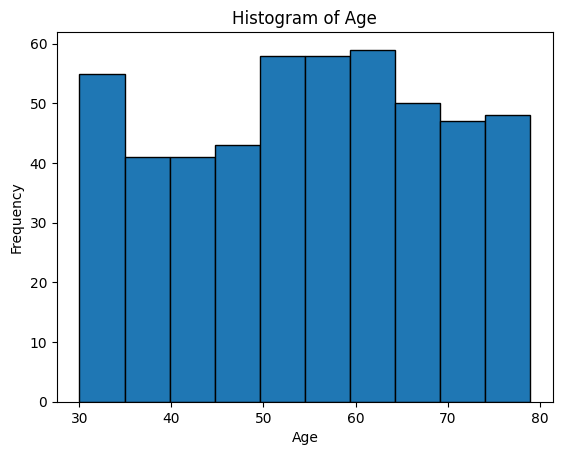

In [5]:
import matplotlib.pyplot as plt

plt.hist(df['Age'], bins=10, edgecolor='black')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.title('Histogram of Age')
plt.show()

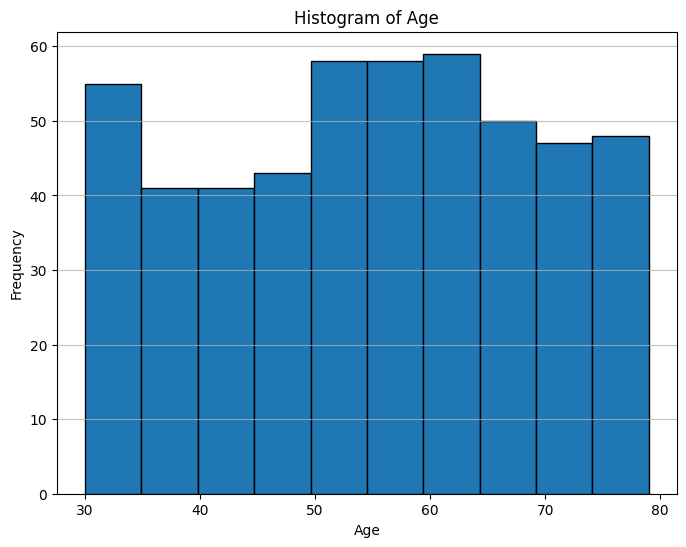

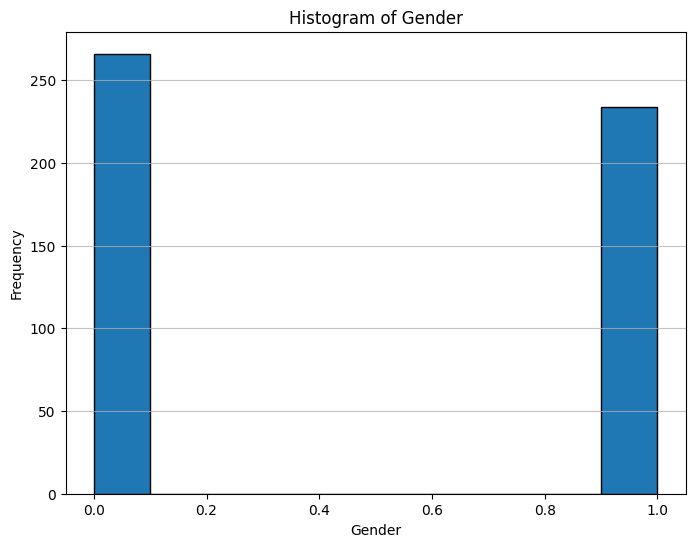

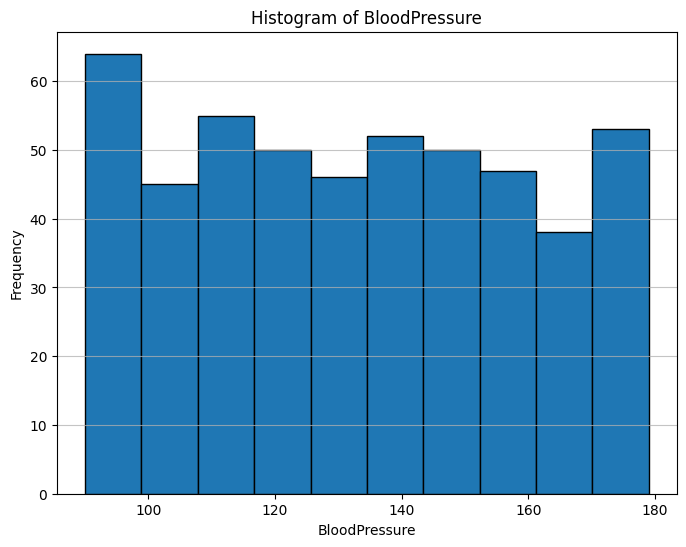

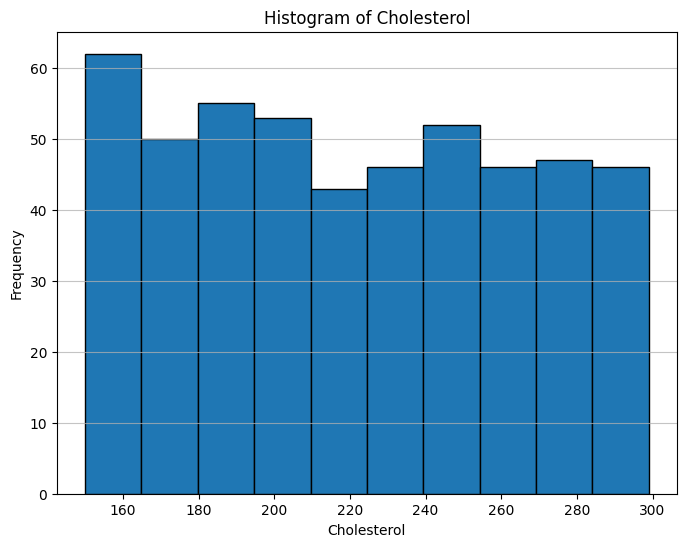

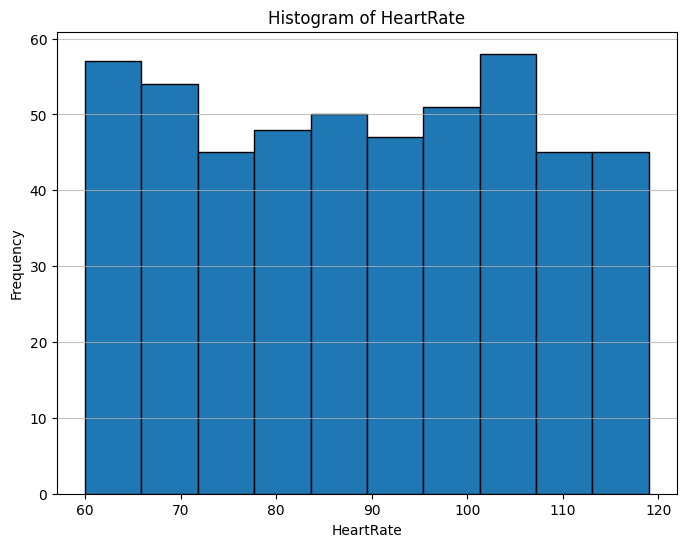

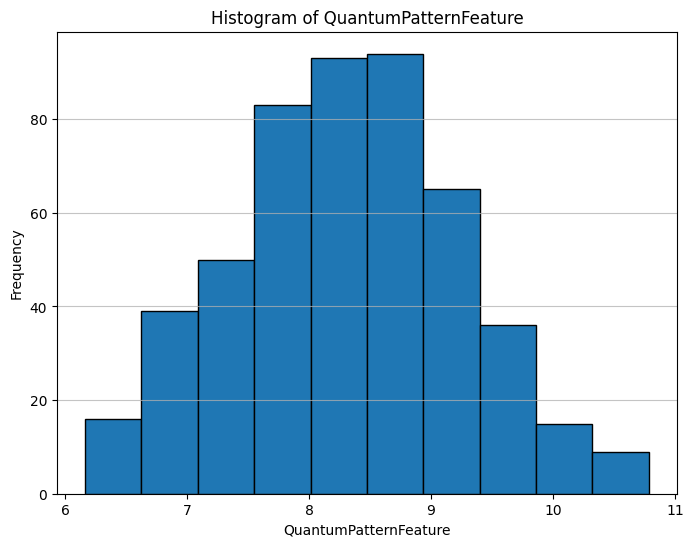

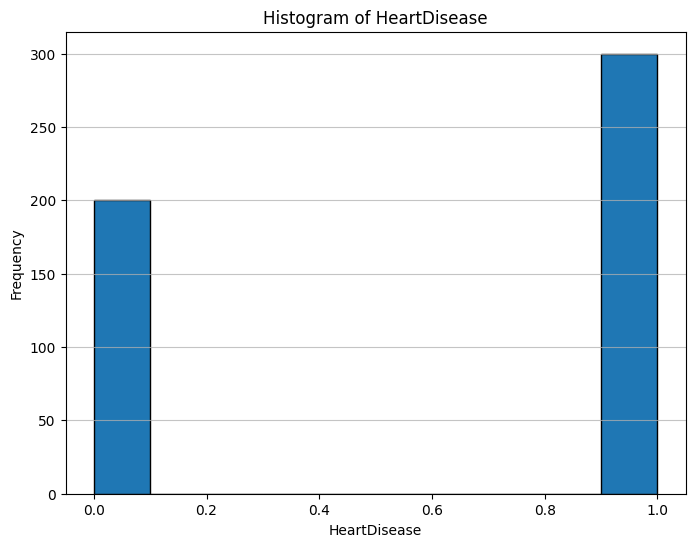

In [6]:
import matplotlib.pyplot as plt

# Identify numerical columns (excluding potential ID columns if any)
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns

for col in numerical_cols:
    plt.figure(figsize=(8, 6))
    plt.hist(df[col], bins=10, edgecolor='black')
    plt.xlabel(col)
    plt.ylabel('Frequency')
    plt.title(f'Histogram of {col}')
    plt.grid(axis='y', alpha=0.75)
    plt.show()

In [7]:
y = df['HeartDisease']
X = df.drop('HeartDisease', axis=1).drop('QuantumPatternFeature', axis=1)

categorical_features_X = ['Gender']

numerical_features_X = X.select_dtypes(include=['int64', 'float64']).columns.drop(categorical_features_X)

print("Variable objetivo (y):", y.name)
print("Características numéricas en X:", numerical_features_X.tolist())
print("Características categóricas en X:", categorical_features_X)

Variable objetivo (y): HeartDisease
Características numéricas en X: ['Age', 'BloodPressure', 'Cholesterol', 'HeartRate']
Características categóricas en X: ['Gender']


In [8]:
model = MLPClassifier(hidden_layer_sizes=(5, 10), random_state=42)

In [9]:
num_transformer = StandardScaler()
cat_transformer = OneHotEncoder(drop='first')
preprocessor = ColumnTransformer(
    transformers=[
        ('num', num_transformer, numerical_features_X),
        ('cat', cat_transformer, categorical_features_X)
    ])
pipeline = Pipeline(
    steps=[('preprocessor', preprocessor),
           ('classifier', model)])
pipeline.fit(X, y)

/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  Index(['Age', 'BloodPressure', 'Cholesterol', 'HeartRate'], dtype='object')),
                                                 ('cat',
                                                  OneHotEncoder(drop='first'),
                                                  ['Gender'])])),
                ('classifier',
                 MLPClassifier(hidden_layer_sizes=(5, 10), random_state=42))])

In [10]:
pipeline.score(X, y)

0.804

In [11]:
from sklearn.model_selection import cross_val_score
cross_val_score(pipeline, X, y, scoring ='roc_auc', cv = 10)

/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptro

array([0.875     , 0.88166667, 0.76833333, 0.88      , 0.69083333,
       0.93333333, 0.86333333, 0.80666667, 0.89916667, 0.90166667])

In [12]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

pipeline.fit(X_train, y_train)

y_pred = pipeline.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))

/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


Accuracy: 0.83

Classification Report:
               precision    recall  f1-score   support

           0       0.87      0.68      0.76        40
           1       0.81      0.93      0.87        60

    accuracy                           0.83       100
   macro avg       0.84      0.80      0.81       100
weighted avg       0.84      0.83      0.83       100


Confusion Matrix:
 [[27 13]
 [ 4 56]]


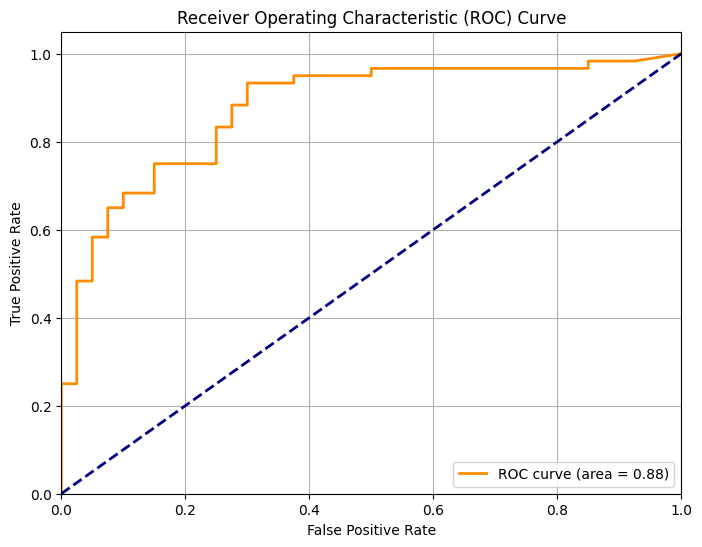

In [13]:
from sklearn.metrics import roc_curve, auc, RocCurveDisplay
import matplotlib.pyplot as plt

# Get probability predictions for the positive class (class 1)
y_pred_proba = pipeline.predict_proba(X_test)[:, 1]

# Calculate ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
roc_auc = auc(fpr, tpr)

# Plot ROC curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

# Optimización Bayesiana

In [16]:
from skopt import gp_minimize
from skopt.space import Integer as SKInt
from sklearn.model_selection import cross_val_score
from sklearn.neural_network import MLPClassifier
from sklearn.pipeline import Pipeline
import numpy as np

def objective(params):
    l1, l2, l3 = params
    mlp = MLPClassifier(
        hidden_layer_sizes=(l1, l2, l3),
        random_state=42,
        max_iter=500
    )
    pipe = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('classifier', mlp)
    ])
    scores = cross_val_score(pipe, X_train, y_train, cv=5, scoring='roc_auc')
    return -np.mean(scores)

space = [
    SKInt(2, 6,  name='layer_1'),
    SKInt(5, 15, name='layer_2'),
    SKInt(3, 16, name='layer_3'),
]

result = gp_minimize(
    func=objective,
    dimensions=space,
    n_calls=30,
    random_state=42,
    verbose=True
)

best_l1, best_l2, best_l3 = result.x
print(f"\nMejores capas: ({best_l1}, {best_l2}, {best_l3})")
print(f"Mejor ROC-AUC (CV): {-result.fun:.4f}")

# Reentrenar con los mejores hiperparámetros
best_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', MLPClassifier(
        hidden_layer_sizes=(best_l1, best_l2, best_l3),
        random_state=42,
        max_iter=500
    ))
])
best_pipeline.fit(X_train, y_train)

y_pred = best_pipeline.predict(X_test)
print("\nAccuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Iteration No: 1 started. Evaluating function at random point.


/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptro

Iteration No: 1 ended. Evaluation done at random point.
Time taken: 11.4489
Function value obtained: -0.8262
Current minimum: -0.8262
Iteration No: 2 started. Evaluating function at random point.


/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration No: 2 ended. Evaluation done at random point.
Time taken: 9.7811
Function value obtained: -0.7911
Current minimum: -0.8262
Iteration No: 3 started. Evaluating function at random point.


...

/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptro

Iteration No: 29 ended. Search finished for the next optimal point.
Time taken: 4.2505
Function value obtained: -0.8323
Current minimum: -0.8408
Iteration No: 30 started. Searching for the next optimal point.


/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration No: 30 ended. Search finished for the next optimal point.
Time taken: 3.0424
Function value obtained: -0.8400
Current minimum: -0.8408

Mejores capas: (5, 15, 9)
Mejor ROC-AUC (CV): 0.8408

Accuracy: 0.83

Classification Report:
               precision    recall  f1-score   support

           0       0.83      0.72      0.77        40
           1       0.83      0.90      0.86        60

    accuracy                           0.83       100
   macro avg       0.83      0.81      0.82       100
weighted avg       0.83      0.83      0.83       100



/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(


In [18]:
print(f"\nMejores capas: ({best_l1}, {best_l2}, {best_l3})")
print(f"Mejor ROC-AUC (CV): {-result.fun:.4f}")
print("\nAccuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))


Mejores capas: (5, 15, 9)
Mejor ROC-AUC (CV): 0.8408

Accuracy: 0.83

Classification Report:
               precision    recall  f1-score   support

           0       0.83      0.72      0.77        40
           1       0.83      0.90      0.86        60

    accuracy                           0.83       100
   macro avg       0.83      0.81      0.82       100
weighted avg       0.83      0.83      0.83       100

